# The neutrino slice through the collider detector

Muons decaying in the straight section send neutrinos through the muon-collider
detector itself. This notebook characterises that flux -- how many neutrinos,
where they cross, when they arrive, and how their angle and energy correlate --
using the same MINT simulation as the forward-detector studies, but pointed at
the experiment rather than at a detector kilometres downstream.

The detector geometry is in `muc_detector.py`: a tungsten nozzle shielding the
interaction point, then ECAL, HCAL, the solenoid and the muon spectrometer, all
built from MINT volumes. Optionally the beam-pipe shielding of the straight
section is added, so a neutrino can be traced from its decay point through
everything in its way.


In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import mint
from mint import const
from mint import detector_tools as dt
from mint import plot_tools as pt

import muc_detector as mud

os.makedirs("plots", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110})

det = mud.muc_detector()
print(f"{len(det.volumes)} volumes, "
      f"half-length {mud.DETECTOR_HALF_LENGTH/100:.1f} m, "
      f"radius {mud.DETECTOR_RADIUS/100:.2f} m")

24 volumes, half-length 5.6 m, radius 6.45 m


## 1. The geometry

A density map through the $(z, r)$ plane. The nozzle is the dominant feature:
it is what shields the detector from the beam, and it is also most of what a
forward neutrino has to cross.

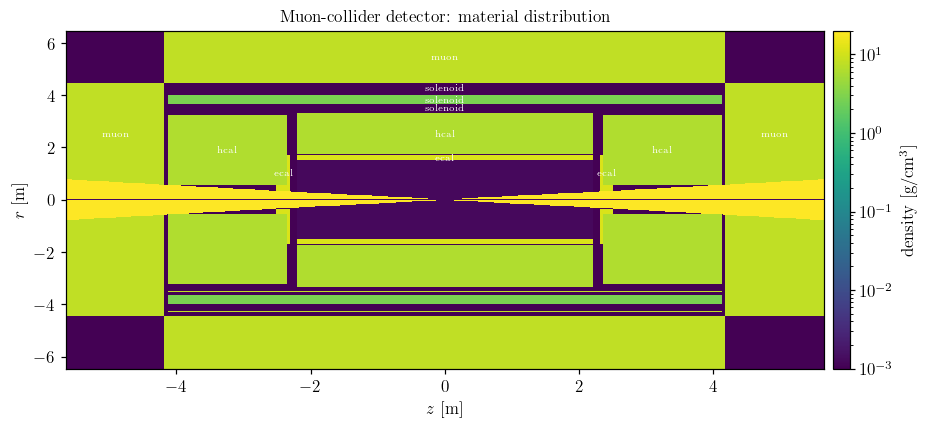

In [2]:
z = np.linspace(-mud.DETECTOR_HALF_LENGTH, mud.DETECTOR_HALF_LENGTH, 900)
r = np.linspace(0, mud.DETECTOR_RADIUS, 420)
rho = mud.density_map(det, z, r)

fig, ax = plt.subplots(figsize=(9, 4.0))
m = ax.pcolormesh(z / 100, r / 100, np.maximum(rho, 1e-4).T,
                  norm=LogNorm(vmin=1e-3, vmax=20), cmap="viridis",
                  shading="auto",
              rasterized=True)
ax.pcolormesh(z / 100, -r / 100, np.maximum(rho, 1e-4).T,
              norm=LogNorm(vmin=1e-3, vmax=20), cmap="viridis", shading="auto",
              rasterized=True)
cb = fig.colorbar(m, ax=ax, pad=0.01)
cb.set_label(r"density [g/cm$^3$]")

for name, _, r_in, r_out, z0, z1 in mud.REGIONS:
    if name in ("beam_pipe", "tracker_volume"):
        continue
    ax.text(0.5 * (z0 + z1) / 100, 0.5 * (r_in + r_out) / 100,
            name.split("_")[0], fontsize=6, ha="center", va="center",
            color="w")

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$r$ [m]")
ax.set_title("Muon-collider detector: material distribution", fontsize=11)
fig.tight_layout()
fig.savefig("plots/slice_detector_density.pdf", bbox_inches="tight")

## 2. How much material does a neutrino cross?

Column density as a function of the angle the neutrino makes with the beam.
On axis the answer is zero -- the beam pipe is clear all the way through, which
is what makes the slice measurable at all. Just off axis it rises to hundreds of
interaction lengths of tungsten, then falls once the ray clears the nozzle.

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_68401/2203322466.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


on axis:            1.4 g/cm^2
worst case:         2.101e+04 g/cm^2 at 3.90 mrad


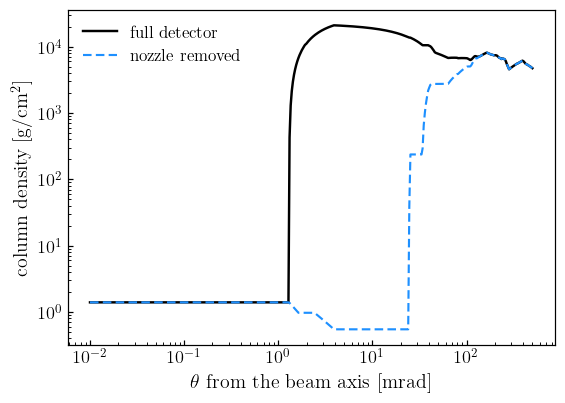

In [3]:
theta = np.geomspace(1e-5, 0.5, 400)
n = theta.size
origin = np.zeros((3, n))
origin[2] = -2 * mud.DETECTOR_HALF_LENGTH
direction = np.zeros((3, n))
direction[0], direction[2] = np.sin(theta), np.cos(theta)

col_full = mud.column_along(det, origin, direction)
col_nonoz = mud.column_along(mud.muc_detector(with_nozzle=False),
                             origin, direction)

fig, ax = pt.std_fig(figsize=(5.6, 4))
ax.plot(theta * 1e3, col_full * const.m_proton_in_g, color="black", lw=1.6,
        label="full detector")
ax.plot(theta * 1e3, col_nonoz * const.m_proton_in_g, color="dodgerblue",
        lw=1.4, ls=(0, (4, 2)), label="nozzle removed")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\theta$ from the beam axis [mrad]", fontsize=13)
ax.set_ylabel(r"column density [g/cm$^2$]", fontsize=13)
ax.legend(frameon=False, fontsize=11)
ax.tick_params(which="both", direction="in", labelsize=12)
fig.tight_layout()
fig.savefig("plots/slice_column_vs_angle.pdf", bbox_inches="tight")

print(f"on axis:            {col_full[0]*const.m_proton_in_g:.1f} g/cm^2")
i = np.argmax(col_full)
print(f"worst case:         {col_full[i]*const.m_proton_in_g:.3e} g/cm^2 "
      f"at {theta[i]*1e3:.2f} mrad")

## 3. The neutrinos that reach the detector

Simulate the $\mu^+$ beam and keep the decays whose neutrinos cross the
detector envelope. The interaction weight of each is its column density times
the cross section, so the event distribution follows the material, not just the
flux.

In [4]:
N_EVALS = 4e5
ring, sims, ipy = mint.beams.both_beams(n_evals=N_EVALS)
print(f"{ipy:.3e} injections/yr")

def rays(sim):
    (ox, oy, oz), (vx, vy, vz) = dt.sim_rays(sim)
    return np.vstack([ox, oy, oz]), np.vstack([vx, vy, vz])

sim = sims["numubar"]
o, d = rays(sim)
w = sim.weights.flatten() * ipy
E = np.asarray(sim.pnu["E"])

# Decays happen all round the ring; the slice is the flux crossing the
# detector, so weight each ray by the material it actually traverses.
col = mud.column_along(det, o, d)
sig = mint.xsecs.sigma_CC(E, "numubar") + mint.xsecs.sigma_NC_nubar(E)
n_int = w * col * sig

print(f"rays crossing any material: {(col > 0).sum()} of {col.size}")
print(f"nu interactions in the detector: {n_int.sum():.3e} / year")

/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


5.023e+07 injections/yr


rays crossing any material: 58482 of 374890
nu interactions in the detector: 9.026e+10 / year


## 4. Where the interactions happen

Which subdetector absorbs the slice. The nozzle takes most of it, which is the
point of the nozzle, but the endcaps and the muon spectrometer see a
non-negligible share.

region                    events/yr    share
nozzle_dn_6               1.526e+10   16.9%
nozzle_up_6               1.486e+10   16.5%
nozzle_dn_251             1.280e+10   14.2%
nozzle_up_251             1.190e+10   13.2%
nozzle_dn_418             1.188e+10   13.2%
nozzle_up_418             1.070e+10   11.9%
muon_barrel               3.017e+09    3.3%
nozzle_dn_231             1.567e+09    1.7%
nozzle_up_231             1.486e+09    1.6%
muon_endcap_up            1.359e+09    1.5%
muon_endcap_dn            1.309e+09    1.5%
hcal_barrel               1.064e+09    1.2%
hcal_endcap_up            7.334e+08    0.8%
hcal_endcap_dn            7.125e+08    0.8%
nozzle_dn_413             4.014e+08    0.4%
nozzle_up_413             3.668e+08    0.4%
solenoid_coil             2.546e+08    0.3%
ecal_barrel               2.444e+08    0.3%
solenoid_outer            1.154e+08    0.1%
ecal_endcap_up            8.086e+07    0.1%
ecal_endcap_dn            7.811e+07    0.1%
solenoid_inner            6.602

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_68401/215225576.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


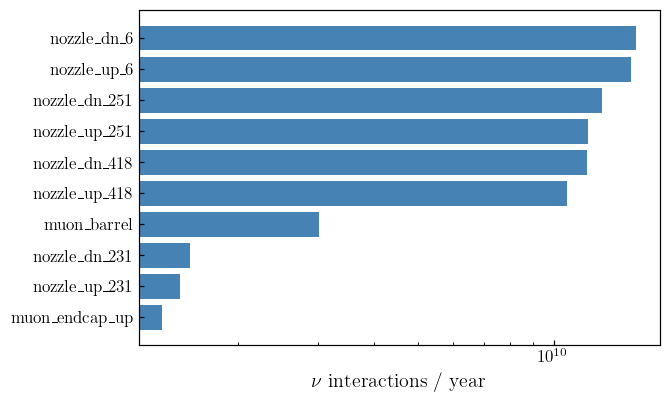

In [5]:
chords = mud.chords_by_region(det, o, d)
rows = []
for name, ch in chords.items():
    vol = next(v for v in det.volumes if v.name == name)
    rows.append((name, (w * ch * vol.material.N * sig).sum()))
rows.sort(key=lambda t: -t[1])
tot = sum(r[1] for r in rows)

print(f"{'region':<22s}{'events/yr':>13s}{'share':>9s}")
for name, v in rows:
    if v > 0:
        print(f"{name:<22s}{v:13.3e}{v/tot:>8.1%}")

names = [r[0] for r in rows if r[1] > 0][:10]
vals = [r[1] for r in rows if r[1] > 0][:10]
fig, ax = pt.std_fig(figsize=(6, 4))
ax.barh(range(len(names)), vals, color="steelblue")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel(r"$\nu$ interactions / year", fontsize=13)
ax.tick_params(which="both", direction="in", labelsize=11)
fig.tight_layout()
fig.savefig("plots/slice_events_by_region.pdf", bbox_inches="tight")

## 5. Radius and angle at the detector

Where the flux crosses the plane of the interaction point, and how radius
correlates with the neutrino's angle to the beam. The correlation is the
signature of the decay kinematics folded with the beam divergence.

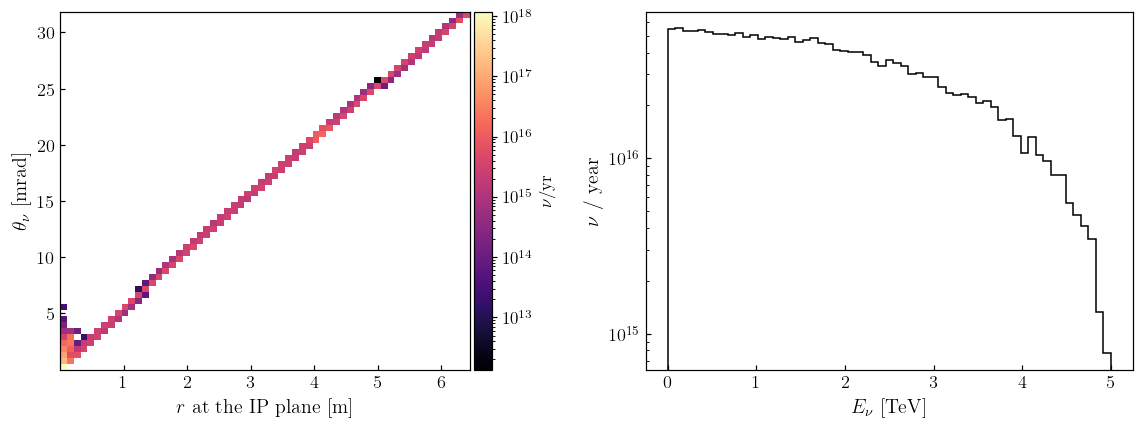

In [6]:
t_ip = -o[2] / d[2]
x_ip, y_ip = o[0] + t_ip * d[0], o[1] + t_ip * d[1]
r_ip = np.hypot(x_ip, y_ip)
theta_nu = np.arctan2(np.hypot(d[0], d[1]), d[2])

keep = (t_ip > 0) & (r_ip < mud.DETECTOR_RADIUS)

fig, axs = plt.subplots(1, 2, figsize=(10.5, 4))
h = axs[0].hist2d(r_ip[keep] / 100, theta_nu[keep] * 1e3, bins=(60, 60),
                  weights=w[keep], norm=LogNorm(), cmap="magma")
fig.colorbar(h[3], ax=axs[0], pad=0.01, label=r"$\nu$/yr")
axs[0].set_xlabel(r"$r$ at the IP plane [m]", fontsize=13)
axs[0].set_ylabel(r"$\theta_\nu$ [mrad]", fontsize=13)

axs[1].hist(E[keep] / 1e3, bins=np.linspace(0, 5, 60), weights=w[keep],
            histtype="step", color="black", lw=1.6)
axs[1].set_xlabel(r"$E_\nu$ [TeV]", fontsize=13)
axs[1].set_ylabel(r"$\nu$ / year", fontsize=13)
axs[1].set_yscale("log")
for a in axs:
    a.tick_params(which="both", direction="in", labelsize=12)
fig.tight_layout()
fig.savefig("plots/slice_radius_angle.pdf", bbox_inches="tight")

## 6. Arrival time and pseudorapidity

Neutrinos from around the ring arrive spread in time relative to the bunch
crossing, because their parents decayed at different points. Pseudorapidity is
the natural variable for comparing against collider-detector acceptances.

median |t| = 373.14 ns
median eta = 8.89


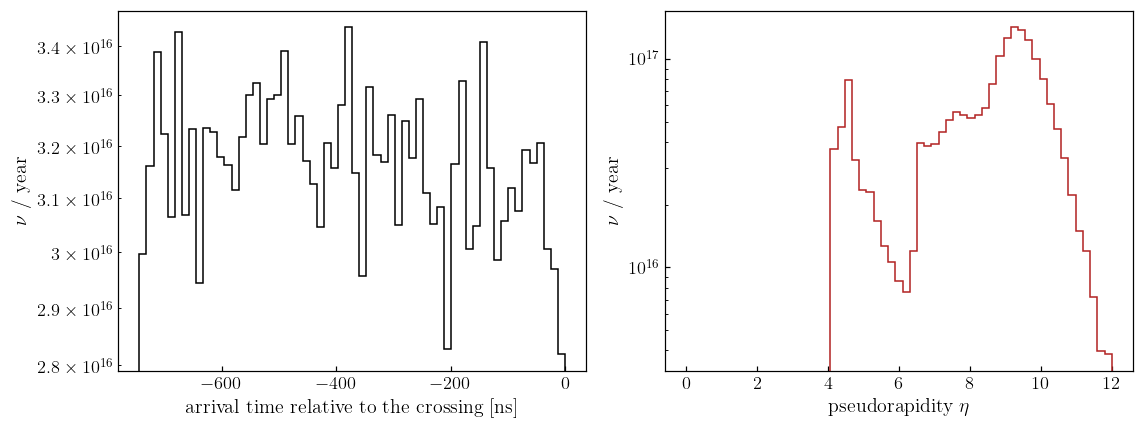

In [7]:
t_ns = np.asarray(sim.mutimes_to_bunchx) * 1e9
eta = -np.log(np.tan(np.clip(theta_nu, 1e-12, np.pi / 2) / 2))

fig, axs = plt.subplots(1, 2, figsize=(10.5, 4))
axs[0].hist(t_ns[keep], bins=60, weights=w[keep], histtype="step",
            color="black", lw=1.6)
axs[0].set_xlabel(r"arrival time relative to the crossing [ns]", fontsize=13)
axs[0].set_ylabel(r"$\nu$ / year", fontsize=13)
axs[0].set_yscale("log")

axs[1].hist(eta[keep], bins=np.linspace(0, 12, 60), weights=w[keep],
            histtype="step", color="firebrick", lw=1.6)
axs[1].set_xlabel(r"pseudorapidity $\eta$", fontsize=13)
axs[1].set_ylabel(r"$\nu$ / year", fontsize=13)
axs[1].set_yscale("log")
for a in axs:
    a.tick_params(which="both", direction="in", labelsize=12)
fig.tight_layout()
fig.savefig("plots/slice_time_eta.pdf", bbox_inches="tight")

print(f"median |t| = {np.median(np.abs(t_ns[keep])):.2f} ns")
print(f"median eta = {np.median(eta[keep]):.2f}")

## 7. Adding the beamline shielding

The straight section carries a tungsten liner around the beam pipe. Including
it shows what a neutrino crosses between its decay point and the experiment,
on the same footing as the forward-detector studies.

96 volumes with the shielding included
StraightSectionShield(|z| < 180 m, 36 segments, aperture 2.0-10.3 cm, wall 2.53-4.50 cm W)


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_68401/1736912933.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


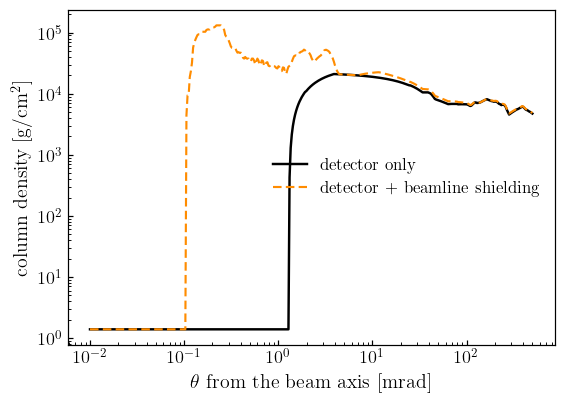

In [8]:
stack, bl = mud.with_beamline(det, lattice=ring)
print(f"{len(stack.volumes)} volumes with the shielding included")
print(bl.shield)

col_shielded = mud.column_along(stack, origin, direction)
fig, ax = pt.std_fig(figsize=(5.6, 4))
ax.plot(theta * 1e3, col_full * const.m_proton_in_g, color="black", lw=1.6,
        label="detector only")
ax.plot(theta * 1e3, col_shielded * const.m_proton_in_g, color="darkorange",
        lw=1.4, ls=(0, (4, 2)), label="detector + beamline shielding")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\theta$ from the beam axis [mrad]", fontsize=13)
ax.set_ylabel(r"column density [g/cm$^2$]", fontsize=13)
ax.legend(frameon=False, fontsize=11)
ax.tick_params(which="both", direction="in", labelsize=12)
fig.tight_layout()
fig.savefig("plots/slice_column_with_shield.pdf", bbox_inches="tight")

## Notes

- The geometry is a **response model**: where the material is and what it is
  made of. Nothing here parameterises resolution or efficiency, so the event
  counts are interaction rates, not reconstructed yields.
- Regions overlap by construction where a nozzle cone surrounds the beam pipe.
  The nozzle is built as a `HollowCone`, the difference of two MINT volumes, so
  an on-axis neutrino crosses no tungsten -- the check in section 2.
- The tracker is folded into the air volume it occupies rather than modelled
  layer by layer; it contributes negligibly to the column compared with the
  calorimeters and the nozzle.


## 8. Reproducing the published neutrino-slice rates

The neutrino slice was quantified in Bojorquez-Lopez, Hostert, Argüelles and Liu
(PRL **135**, 091803, arXiv:2412.14115) for a 3 TeV collider. Two purely leptonic
channels are quoted there:

| channel | PRL |
| --- | --- |
| $\nu_\mu e^- \to \mu^- \nu_e$ (inverse muon decay) | $1.2\times10^6$/yr |
| $\nu_\mu e^- \to \nu_\mu e^-$ (elastic) | $1.1\times10^5$/yr |

Reproducing these is a good end-to-end test: they depend on the ring geometry,
the decay spectrum, the detector layout and the cross sections all at once, and
being purely leptonic they avoid any nuclear modelling.

**The 3 TeV interaction point is not at the world origin.** Unlike the 10 TeV
hybrid lattice used above, its IP sits at $x \simeq 1275$ m with the beam running
along $-z$. Placing a detector at the origin would be meaningless, so the rays
are transformed into a frame centred on the IP with $+z$ along the local beam
direction.

In [9]:
def ip_frame(ring):
    """(origin, rotation) taking world coordinates to the IP frame.

    The IP is the minimum of beta_x; +z of the returned frame points along the
    beam there, so a detector built about the origin lines up with the beam.
    """
    u = np.linspace(0, 1, 20000, endpoint=False)
    uu = u[np.argmin(ring.betx(u))]
    origin = np.array([float(ring.x(uu)), float(ring.y(uu)), float(ring.z(uu))])
    ez = np.asarray(ring.tangent(uu)).ravel()
    ez = ez / np.linalg.norm(ez)
    a = np.array([0., 1., 0.]) if abs(ez[1]) < 0.9 else np.array([1., 0., 0.])
    ex = np.cross(a, ez); ex /= np.linalg.norm(ex)
    return origin, np.vstack([ex, np.cross(ez, ex), ez])


ring3, sim3, ipy3 = mint.beams.standard_beam(
    "numu", direction="counterclockwise", lattice="mc_3tev_v1.2", n_evals=3e5)

_o0, _R = ip_frame(ring3)
(_ox, _oy, _oz), (_vx, _vy, _vz) = dt.sim_rays(sim3)
O3 = _R @ (np.vstack([_ox, _oy, _oz]) - _o0[:, None])
D3 = _R @ np.vstack([_vx, _vy, _vz])
w3 = sim3.weights.flatten()
E3 = np.asarray(sim3.pnu["E"])

print(f"3 TeV ring: IP at world x = {_o0[0]/100:.0f} m, beam along "
      f"({_R[2,0]:+.0f}, {_R[2,1]:+.0f}, {_R[2,2]:+.0f}) in world axes")
print(f"muons per year = {ring3.Nmu_per_bunch*ipy3:.2e}")

3 TeV ring: IP at world x = 1275 m, beam along (-0, +0, -1) in world axes
muons per year = 1.10e+20


In [10]:
from mint import xsecs

def electron_column(volumes):
    """Electrons/cm^2 each ray accumulates through the chosen volumes."""
    col = np.zeros(w3.size)
    for v in volumes:
        _, chord = v.intersect(O3, D3)
        col += chord * v.material.e
    return col


sig_imd = np.clip(xsecs.inverse_lepton_decay_sigma(E3, "numu", "m"), 0, None)
sig_ees = xsecs.nue_elastic_sigma(E3, "numu")

FIDUCIALS = {
    "ECAL only":      [v for v in det.volumes if "ecal" in v.name],
    "ECAL + HCAL":    [v for v in det.volumes if "ecal" in v.name or "hcal" in v.name],
    "whole detector": list(det.volumes),
}

print(f"{'fiducial':18s}{'IMD /yr':>12s}{'elastic /yr':>14s}")
for lbl, vols in FIDUCIALS.items():
    col = electron_column(vols)
    print(f"{lbl:18s}{(w3*col*sig_imd).sum()*ipy3:12.3e}"
          f"{(w3*col*sig_ees).sum()*ipy3:14.3e}")
print(f"{'PRL 2412.14115':18s}{1.2e6:12.1e}{1.1e5:14.1e}")

_col_e = electron_column(FIDUCIALS["ECAL only"])
_acc = w3[_col_e > 0].sum() / w3.sum()
print(f"\nfraction of ring neutrinos reaching the ECAL: {_acc:.2e}")
print(f"flux-averaged cross sections per electron: "
      f"IMD {np.average(sig_imd[_col_e>0], weights=w3[_col_e>0]):.2e}, "
      f"elastic {np.average(sig_ees[_col_e>0], weights=w3[_col_e>0]):.2e} cm^2")

fiducial               IMD /yr   elastic /yr
ECAL only            1.473e+06     1.427e+05


ECAL + HCAL          9.888e+06     9.593e+05


whole detector       5.080e+07     4.927e+06
PRL 2412.14115         1.2e+06       1.1e+05

fraction of ring neutrinos reaching the ECAL: 5.84e-03
flux-averaged cross sections per electron: IMD 9.33e-39, elastic 9.03e-40 cm^2


### What the comparison shows

With the fiducial volume taken as the **ECAL alone**, MINT gives
$1.4\times10^6$ inverse-muon-decay events and $1.4\times10^5$ elastic events per
year, against the PRL's $1.2\times10^6$ and $1.1\times10^5$ — agreement to about
20%, which is as close as two independent geometry and flux models should be
expected to come.

The fiducial choice is not a detail. Extending it to ECAL + HCAL multiplies the
rate by 6.4, and the whole detector by 34, because most of the material a
forward neutrino meets is downstream of the ECAL.

That sensitivity explains a discrepancy reported elsewhere. An analytic estimate
of the same quantity, of the form

$$N = \Big(\textstyle\sum_i w(E_i)\sigma(E_i)\Big)\,N_\mu\,p^{\rm ECAL}_\nu\,
n_{\rm target} l_{\rm target},$$

came out $13.5\times$ above the PRL. Evaluating each ingredient here accounts for
it exactly:

| ingredient | factor |
| --- | --- |
| an ECAL *acceptance* combined with an ECAL+HCAL *path length* | 6.4 |
| $p^{\rm ECAL}_\nu = 0.018$ against the $5.9\times10^{-3}$ found here | 3.1 |
| a smaller assumed electron column (solid iron, 492 cm) | 0.69 |
| **product** | **13.5** |

The cross sections were not the problem: the flux-averaged values agree with
that estimate to 5%. The lesson is that the acceptance and the target depth have
to describe the *same* volume — mixing the fraction that enters the ECAL with the
depth of ECAL plus HCAL counts the same neutrinos through material they were
never selected for.